<a href="https://colab.research.google.com/github/Rio-HEPLab/ML4Physics/blob/PPGF-2025-1/20-GAN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generative Adversarial Networks

[Generative Adversarial Nets](https://arxiv.org/pdf/1406.2661)

Two models:
* **Generator**: aims to generate new data similar to the expected one.
* **Discriminator**: aims to recognize if an input data is 'real' — belongs to the original dataset – or if it is 'fake' (generated).

* **Generator Network**: Generates realistic images, after training, from random samples in latent space.

* **Discriminator Network**: Classifies whether an image is real (1) or fake (0).

* **Training GANs (competition)**: The Generator learns how to create ralistic data to the Discriminator, which tries to distinguish between real and fake.
    
### Network Design

<figure>
<img src="https://raw.githubusercontent.com/Rio-HEPLab/ML4Physics/PPGF-2025-1/pics/GAN-Digits.jpg" width=600>
<figcaption>Fig.1: GAN architecture. Credits: https://developer.ibm.com/articles/generative-adversarial-networks-explained/</figcaption>
</figure>

### Cost function

Minimax cost function:

$$ \underset{\theta_{g}}{min} \: \underset{\theta_{d}}{max} \; V(D,G) = \mathbb{E}_{x\sim p_{data}(x)}[log D_{\theta_{d}}(x)] + \mathbb{E}_{z\sim p_{z}(z)}[log(1 - D_{\theta_{d}}(G_{\theta_{g}}(z)))]$$

* $D_{\theta_{d}}$ wants to maximize  objective such that $D(x)$ is close to 1 (real) and $D(G(z))$ is close to 0 (fake).
* $G_{\theta_{g}}$ wants to minimize objective such that $D(G(z))$ is close to 1 (discriminator is fooled into thinking generated G(z) is real).

Alternate between:
1. Gradient ascent on D
$$\underset{\theta_{d}}{max} [\mathbb{E}_{x\sim p_{data}(x)}log D_{\theta_{d}}(x) + \mathbb{E}_{z\sim p_{z}(z)}log(1 - D_{\theta_{d}}(G_{\theta_{g}}(z)))]$$

2. Gradient ascent on generator, different objective
$$\underset{\theta_{g}}{max}[\mathbb{E}_{z\sim p_{z}(z)}[log( D_{\theta_{d}}(G_{\theta_{g}}(z)))] $$

(Maximize likelihood of discriminator being wrong instead of minimizing likelihood of discriminator being correct, same objetive of fooling discriminator)

* The Discriminator is trained to correctly classify the input data as either real or fake.
    * It's weights are updated as to maximize the probability that any real data input x is classified as belonging to the real dataset, while minimizing the probability that any fake image is classified as belonging to the real dataset.
    * The loss/error function used maximizes the function D(x), and it also minimizes D(G(z)).
* The Generator is trained to fool the Discriminator by generating data as realistic as possible. It's weighta are optimized to maximize the probability that any fake image is classified as belonging to the real dataset. This means that the loss/error function used for this network maximizes D(G(z)).

### Load data

In [1]:
import numpy as np
import matplotlib.pyplot as plt


#### MNIST data

In [2]:
import tensorflow as tf
tf.config.run_functions_eagerly(True) # This ensures eager execution within tf.function

# from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization
from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.optimizers.legacy import Adam
# from keras.optimizers import SGD
from tensorflow.keras import initializers

In [3]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
num_samples = 20000
X_train = X_train[ : num_samples ]
y_train = y_train[ : num_samples ]
print ( X_train.shape )

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(20000, 28, 28)


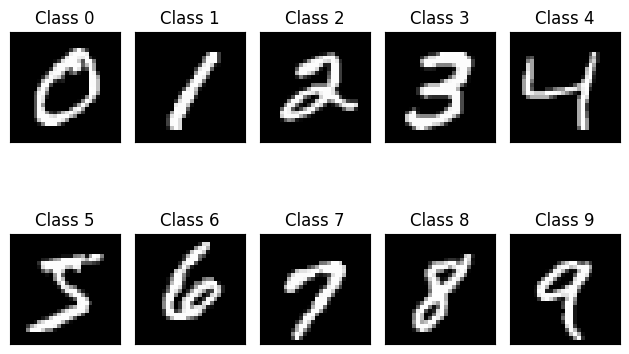

In [4]:
fig = plt.figure()
for i in range(10):
    plt.subplot(2, 5, i+1)
    x_y = X_train[y_train == i]
    plt.imshow(x_y[0], cmap='gray', interpolation='none')
    plt.title("Class %d" % (i))
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

#### Reshaping and normalizing the inputs

In [5]:
print('X_train.shape', X_train.shape)

# Reshape and normalize
X_train = X_train.reshape( X_train.shape[0], 28*28 )
X_train = ( X_train.astype('float32') / 255 - 0.5 ) * 2
print('X_train reshape:', X_train.shape)

# Batch and shuffle the data
batch_size = 256
train_dataset = tf.data.Dataset.from_tensor_slices( X_train ).shuffle(num_samples).batch( batch_size )

X_train.shape (20000, 28, 28)
X_train reshape: (20000, 784)


### Model

#### Generator

In [6]:
# latent space dimension
latent_dim = 100

# image dimension 28x28
img_dim = 784

kernel_init = initializers.RandomNormal(stddev=0.02)

# Generator network
generator = Sequential()

# Input layer and hidden layer 1
generator.add( Dense( 128, input_shape=(latent_dim,), kernel_initializer=kernel_init ) )
generator.add( LeakyReLU(alpha=0.2) )
generator.add( BatchNormalization(momentum=0.8) )

# Hidden layer 2
generator.add( Dense(256) )
generator.add( LeakyReLU(alpha=0.2) )
generator.add( BatchNormalization(momentum=0.8) )

# Hidden layer 3
generator.add( Dense(512) )
generator.add( LeakyReLU(alpha=0.2) )
generator.add( BatchNormalization(momentum=0.8) )

# Output layer
generator.add( Dense(img_dim, activation='tanh') )


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [7]:
# Summary of generator
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 583,312 (2.23 MB)

 Trainable params: 581,520 (2.22 MB)

 Non-trainable params: 1,792 (7.00 KB)

#### Discriminator

In [8]:
# Discriminator network
discriminator = Sequential()

# Input layer and hidden layer 1
discriminator.add (Dense(128, input_shape=(img_dim,), kernel_initializer=kernel_init) )
discriminator.add (LeakyReLU(alpha=0.2) )

# Hidden layer 2
discriminator.add( Dense(256) )
discriminator.add( LeakyReLU(alpha=0.2) )

# Hidden layer 3
discriminator.add( Dense(512) )
discriminator.add( LeakyReLU(alpha=0.2) )

# Output layer
discriminator.add(Dense(1, activation='sigmoid'))


In [9]:
# Summary of discriminator
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,601 (1.01 MB)

 Trainable params: 265,601 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

### Train

/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:780: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


Epoch: 0, disc. loss: -0.03197164833545685, gen. loss: 2.693453788757324. Time for epoch 1 is 29.281874179840088 sec
Epoch: 1, disc. loss: 0.0055386461317539215, gen. loss: 3.2643446922302246. Time for epoch 2 is 40.94420576095581 sec
Epoch: 2, disc. loss: 0.051202572882175446, gen. loss: 2.8606314659118652. Time for epoch 3 is 40.945289611816406 sec
Epoch: 3, disc. loss: 0.04759135842323303, gen. loss: 3.4015731811523438. Time for epoch 4 is 40.9451858997345 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


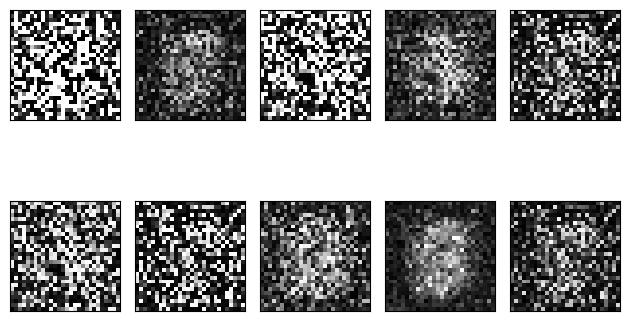

Epoch: 4, disc. loss: 0.1300574541091919, gen. loss: 2.767240524291992. Time for epoch 5 is 29.10792064666748 sec
Epoch: 5, disc. loss: 0.19315096735954285, gen. loss: 2.4940414428710938. Time for epoch 6 is 40.94767689704895 sec
Epoch: 6, disc. loss: 0.19623510539531708, gen. loss: 2.4224276542663574. Time for epoch 7 is 29.632745504379272 sec
Epoch: 7, disc. loss: 0.2063523232936859, gen. loss: 2.204831123352051. Time for epoch 8 is 40.94568204879761 sec
Epoch: 8, disc. loss: 0.34113284945487976, gen. loss: 1.484189510345459. Time for epoch 9 is 29.04311966896057 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


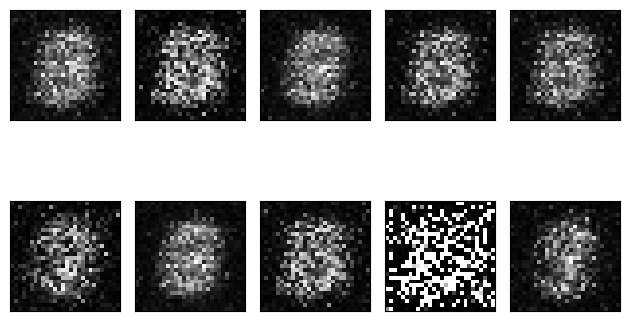

Epoch: 9, disc. loss: 0.3448801636695862, gen. loss: 1.4445056915283203. Time for epoch 10 is 29.72769784927368 sec
Epoch: 10, disc. loss: 0.32639026641845703, gen. loss: 1.4890838861465454. Time for epoch 11 is 30.390694618225098 sec
Epoch: 11, disc. loss: 0.4660266935825348, gen. loss: 1.774298906326294. Time for epoch 12 is 29.290821075439453 sec
Epoch: 12, disc. loss: 0.713792085647583, gen. loss: 2.4689245223999023. Time for epoch 13 is 28.993338108062744 sec
Epoch: 13, disc. loss: 0.4004555642604828, gen. loss: 1.1684539318084717. Time for epoch 14 is 28.494338274002075 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


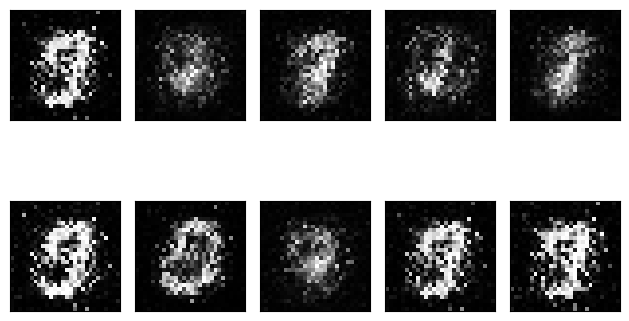

Epoch: 14, disc. loss: 0.6099344491958618, gen. loss: 1.985906720161438. Time for epoch 15 is 41.62866258621216 sec
Epoch: 15, disc. loss: 0.478318989276886, gen. loss: 1.3186290264129639. Time for epoch 16 is 28.633556365966797 sec
Epoch: 16, disc. loss: 0.5506860613822937, gen. loss: 0.5784589052200317. Time for epoch 17 is 28.342284679412842 sec
Epoch: 17, disc. loss: 0.4688529074192047, gen. loss: 1.0821095705032349. Time for epoch 18 is 28.493592500686646 sec
Epoch: 18, disc. loss: 0.5260789394378662, gen. loss: 1.3583343029022217. Time for epoch 19 is 28.334348917007446 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


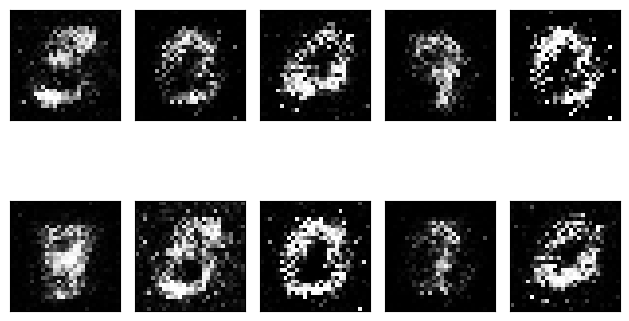

Epoch: 19, disc. loss: 0.6405397653579712, gen. loss: 1.5462185144424438. Time for epoch 20 is 29.95040488243103 sec
Epoch: 20, disc. loss: 0.5171434879302979, gen. loss: 0.9940634965896606. Time for epoch 21 is 28.72629451751709 sec
Epoch: 21, disc. loss: 0.6143906116485596, gen. loss: 1.0858086347579956. Time for epoch 22 is 28.936471700668335 sec
Epoch: 22, disc. loss: 0.5381251573562622, gen. loss: 1.3463246822357178. Time for epoch 23 is 28.688580751419067 sec
Epoch: 23, disc. loss: 0.6064610481262207, gen. loss: 0.5677964687347412. Time for epoch 24 is 29.799318552017212 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


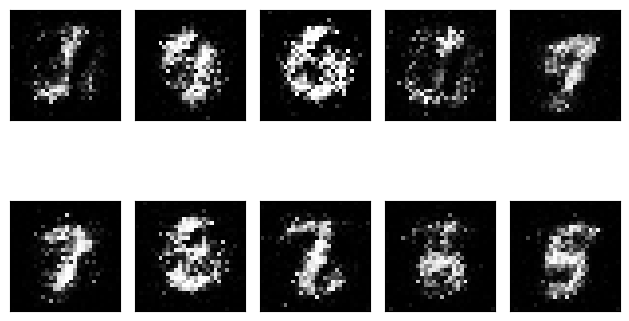

Epoch: 24, disc. loss: 0.6892290115356445, gen. loss: 1.5517711639404297. Time for epoch 25 is 29.180004835128784 sec
Epoch: 25, disc. loss: 0.5936259031295776, gen. loss: 0.9066075086593628. Time for epoch 26 is 40.94618582725525 sec
Epoch: 26, disc. loss: 0.5855406522750854, gen. loss: 1.2183576822280884. Time for epoch 27 is 29.379440784454346 sec
Epoch: 27, disc. loss: 0.5752735733985901, gen. loss: 1.5342462062835693. Time for epoch 28 is 30.396824836730957 sec
Epoch: 28, disc. loss: 0.6008023023605347, gen. loss: 0.48871275782585144. Time for epoch 29 is 29.15616273880005 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


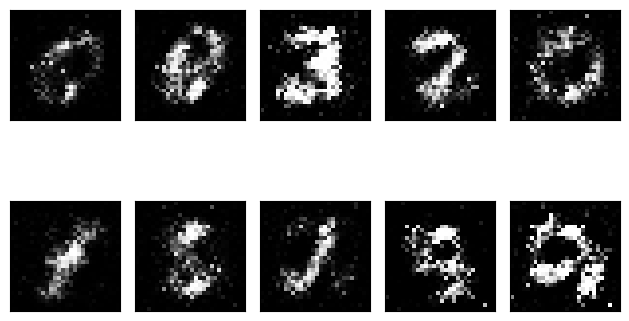

Epoch: 29, disc. loss: 0.5232187509536743, gen. loss: 1.0478792190551758. Time for epoch 30 is 29.50095558166504 sec
Epoch: 30, disc. loss: 0.6133319139480591, gen. loss: 0.6616706848144531. Time for epoch 31 is 40.944562673568726 sec
Epoch: 31, disc. loss: 0.633684515953064, gen. loss: 1.2098774909973145. Time for epoch 32 is 30.4150972366333 sec
Epoch: 32, disc. loss: 0.5000864267349243, gen. loss: 1.1078770160675049. Time for epoch 33 is 29.18190860748291 sec
Epoch: 33, disc. loss: 0.5472822189331055, gen. loss: 1.328872561454773. Time for epoch 34 is 28.707691192626953 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


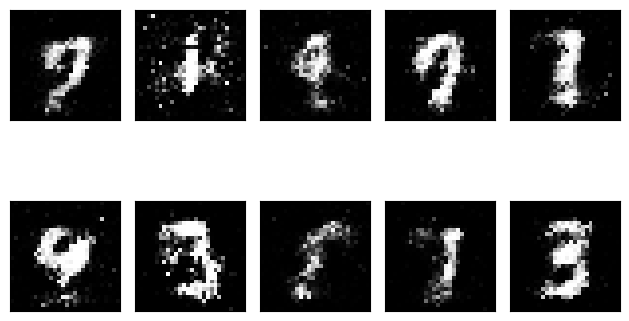

Epoch: 34, disc. loss: 0.5587050914764404, gen. loss: 0.7579196691513062. Time for epoch 35 is 41.48032736778259 sec
Epoch: 35, disc. loss: 0.4863940477371216, gen. loss: 0.9912892580032349. Time for epoch 36 is 28.641748905181885 sec
Epoch: 36, disc. loss: 0.5357166528701782, gen. loss: 1.1267573833465576. Time for epoch 37 is 28.273527145385742 sec
Epoch: 37, disc. loss: 0.551243245601654, gen. loss: 0.7881838083267212. Time for epoch 38 is 28.494937419891357 sec
Epoch: 38, disc. loss: 0.6719608306884766, gen. loss: 1.3928184509277344. Time for epoch 39 is 28.47862696647644 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


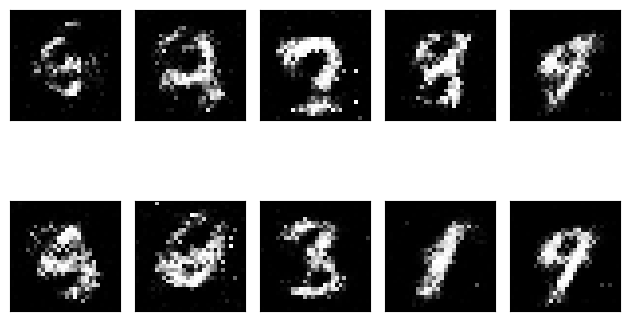

Epoch: 39, disc. loss: 0.7261068820953369, gen. loss: 0.4902496337890625. Time for epoch 40 is 41.56499743461609 sec
Epoch: 40, disc. loss: 0.5672881603240967, gen. loss: 0.7803527116775513. Time for epoch 41 is 28.567424058914185 sec
Epoch: 41, disc. loss: 0.6261159181594849, gen. loss: 1.175081729888916. Time for epoch 42 is 28.54817271232605 sec
Epoch: 42, disc. loss: 0.6343495845794678, gen. loss: 0.8035212755203247. Time for epoch 43 is 28.74363088607788 sec
Epoch: 43, disc. loss: 0.6076013445854187, gen. loss: 0.9212027192115784. Time for epoch 44 is 28.920706272125244 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


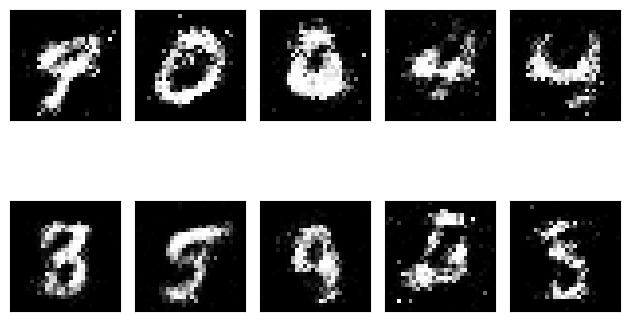

Epoch: 44, disc. loss: 0.5617714524269104, gen. loss: 0.744753360748291. Time for epoch 45 is 29.557138681411743 sec
Epoch: 45, disc. loss: 0.5352387428283691, gen. loss: 1.035935878753662. Time for epoch 46 is 29.071593523025513 sec
Epoch: 46, disc. loss: 0.5345265865325928, gen. loss: 1.0103271007537842. Time for epoch 47 is 29.04893445968628 sec
Epoch: 47, disc. loss: 0.5915789604187012, gen. loss: 0.8936160802841187. Time for epoch 48 is 40.94520092010498 sec
Epoch: 48, disc. loss: 0.5908460021018982, gen. loss: 0.926791250705719. Time for epoch 49 is 30.219160079956055 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


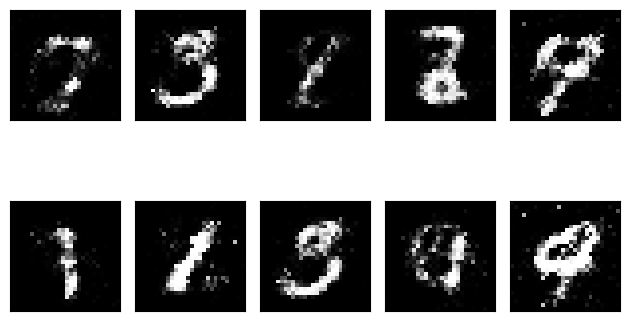

Epoch: 49, disc. loss: 0.7670662999153137, gen. loss: 0.3712766170501709. Time for epoch 50 is 29.543787956237793 sec


In [10]:
import time

# smooth = 0.1
add_noise_labels = True
noise_labels = 0.02

gen_optimizer = Adam( learning_rate=0.0002, beta_1=0.5 )
disc_optimizer = Adam( learning_rate=0.0002, beta_1=0.5 )
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

@tf.function
def train_step( X_real ):
    z = tf.random.normal( [batch_size, latent_dim] )
    X_fake = generator.predict_on_batch( z )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      X_fake = generator( z, training=True )

      real_output = discriminator( X_real, training=True)
      fake_output = discriminator( X_fake, training=True)

      y_real = tf.ones_like(real_output)
      y_fake = tf.zeros_like(fake_output)
      # Add random noise to the labels - important trick!
      if add_noise_labels:
          y_real += noise_labels * tf.random.uniform(tf.shape(y_real))
          y_fake += noise_labels * tf.random.uniform(tf.shape(y_fake))

      real_loss = cross_entropy( y_real, real_output)
      fake_loss = cross_entropy( y_fake, fake_output)
      disc_loss = 0.5 * ( real_loss + fake_loss )

      gen_loss = cross_entropy( tf.ones_like(fake_output), fake_output )

    gen_grads  = gen_tape.gradient( gen_loss, generator.trainable_variables )
    disc_grads = disc_tape.gradient( disc_loss, discriminator.trainable_variables )

    gen_optimizer.apply_gradients( zip( gen_grads, generator.trainable_variables) )
    disc_optimizer.apply_gradients( zip( disc_grads, discriminator.trainable_variables) )

    return (disc_loss, gen_loss)

def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for X_batch in dataset:
      dloss, gloss = train_step( X_batch )

    if (epoch + 1) % 5 == 0:
        samples = 10
        X_ = generator.predict( tf.random.normal( [samples, latent_dim] ) )
        for k in range(samples):
            plt.subplot(2, 5, k+1)
            plt.imshow( X_[k].reshape(28, 28), cmap='gray')
            plt.xticks([])
            plt.yticks([])
        plt.tight_layout()
        plt.show()

    print ( "Epoch: {}, disc. loss: {}, gen. loss: {}.".format( epoch, dloss, gloss ),
            "Time for epoch {} is {} sec".format(epoch + 1, time.time()-start) )

epochs = 50
train(train_dataset, epochs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


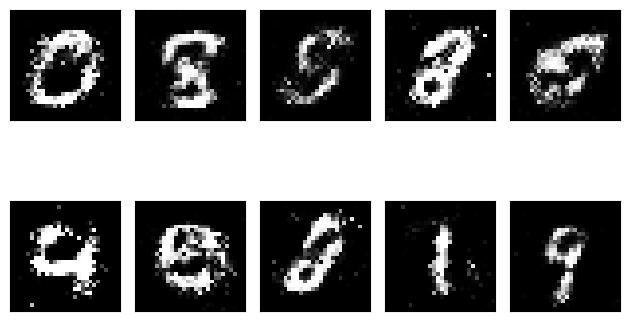

In [11]:
samples = 10
X_ = generator.predict( tf.random.normal( [samples, latent_dim] ) )
for k in range(samples):
    plt.subplot(2, 5, k+1)
    plt.imshow( X_[k].reshape(28, 28), cmap='gray')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()